In [1]:
import pandas as pd

In [2]:
df=pd.read_excel("./Forecasting Case- Study.xlsx")

In [3]:
df.head()

,State,Date,Total,Category
0,Alabama,2019-01-12 00:00:00,109574036.0,Beverages
1,Arizona,2019-01-12 00:00:00,109101594.6,Beverages
2,Arkansas,2019-01-12 00:00:00,58049432.2,Beverages
3,California,2019-01-12 00:00:00,444766890.6,Beverages
4,Colorado,2019-01-12 00:00:00,89816716.3,Beverages


In [4]:
df['Category'].nunique()

1

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

,0
State,0
Date,0
Total,0
Category,0


In [7]:
df.drop('Category',axis=1,inplace=True)

In [8]:
df.head()

,State,Date,Total
0,Alabama,2019-01-12 00:00:00,109574036.0
1,Arizona,2019-01-12 00:00:00,109101594.6
2,Arkansas,2019-01-12 00:00:00,58049432.2
3,California,2019-01-12 00:00:00,444766890.6
4,Colorado,2019-01-12 00:00:00,89816716.3


In [9]:
df.dtypes

,0
State,object
Date,object
Total,float64


In [10]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

,0
State,object
Date,datetime64[ns]
Total,float64


In [11]:
df.head()

,State,Date,Total
0,Alabama,2019-01-12,109574036.0
1,Arizona,2019-01-12,109101594.6
2,Arkansas,2019-01-12,58049432.2
3,California,2019-01-12,444766890.6
4,Colorado,2019-01-12,89816716.3


In [12]:
df['Date'] = df['Date'].dt.strftime('%d/%m/%Y')
df.head()

,State,Date,Total
0,Alabama,12/01/2019,109574036.0
1,Arizona,12/01/2019,109101594.6
2,Arkansas,12/01/2019,58049432.2
3,California,12/01/2019,444766890.6
4,Colorado,12/01/2019,89816716.3


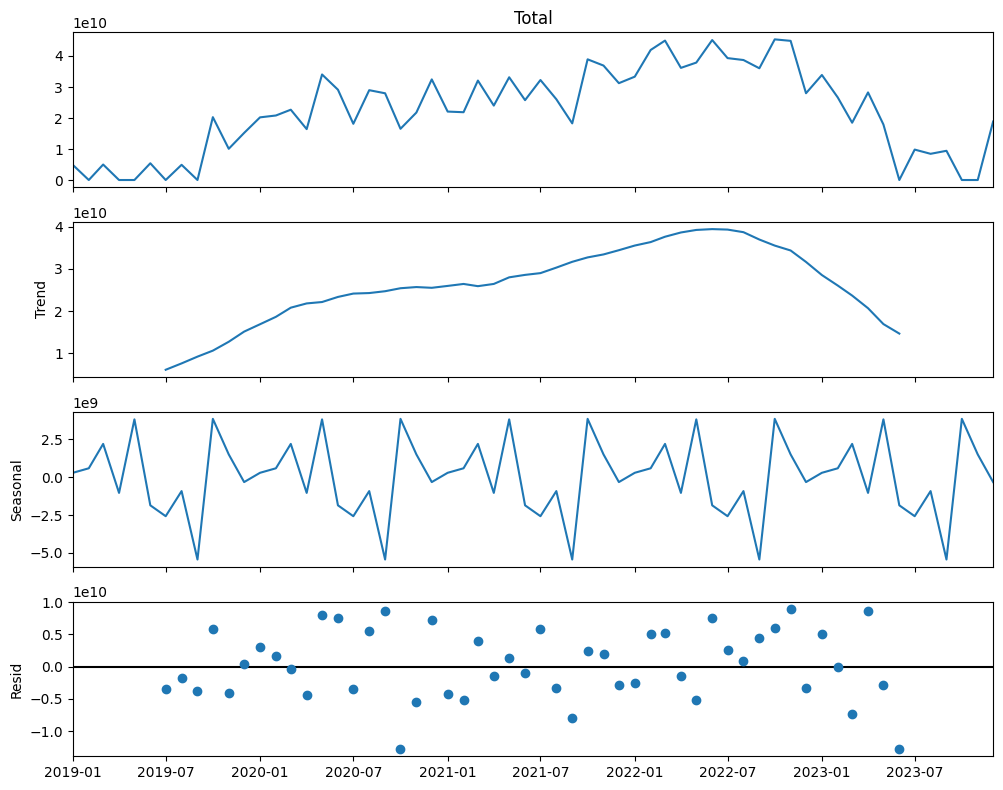

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt


df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df_time_series = df.groupby('Date')['Total'].sum().reset_index()
df_time_series = df_time_series.set_index('Date').sort_index()
monthly_df = df.groupby(pd.Grouper(key='Date', freq='MS'))['Total'].sum()

if len(monthly_df) >= 2 * 12:
    decomposition = seasonal_decompose(monthly_df, model='additive', period=12)


    fig = decomposition.plot()
    fig.set_size_inches(10, 8)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data points to perform seasonal decomposition with a period of 12 months. Need at least two full cycles.")
    print(f"Found {len(monthly_df)} months of data. Minimum required for period 12 is 24 months.")

In [15]:
import numpy as np
import holidays


df['Date'] = pd.to_datetime(df['Date'])
df.sort_values(by=['State', 'Date'], inplace=True)

# 1. Lag features (t-1, t-7, t-30)
df['Total_lag_1'] = df.groupby('State')['Total'].shift(1)
df['Total_lag_7'] = df.groupby('State')['Total'].shift(7)
df['Total_lag_30'] = df.groupby('State')['Total'].shift(30)

# 2. Rolling mean / std
df['Total_rolling_mean_7'] = df.groupby('State')['Total'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())
df['Total_rolling_std_7'] = df.groupby('State')['Total'].transform(lambda x: x.rolling(window=7, min_periods=1).std())
df['Total_rolling_mean_30'] = df.groupby('State')['Total'].transform(lambda x: x.rolling(window=30, min_periods=1).mean())
df['Total_rolling_std_30'] = df.groupby('State')['Total'].transform(lambda x: x.rolling(window=30, min_periods=1).std())


df['day_of_week'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year


try:

    min_year = df['Date'].dt.year.min()
    max_year = df['Date'].dt.year.max()

    us_holidays = holidays.US(years=range(min_year, max_year + 1))

    df['is_holiday'] = df['Date'].dt.date.isin(us_holidays).astype(int)
except ImportError:
    print("The 'holidays' library is not installed. Please install it using '!pip install holidays' to generate holiday features.")
    df['is_holiday'] = 0 # Default to 0 if library is not available




max_date = df['Date'].max()

split_date = max_date - pd.DateOffset(years=1)

# Split the data
df_train = df[df['Date'] <= split_date].copy()
df_val = df[df['Date'] > split_date].copy()

print("Feature engineering complete. Created lag features, rolling statistics, day/month/year, and holiday flag.")
print(f"Data split into training (up to {split_date.strftime('%Y-%m-%d')}) and validation sets.")
print("Shape of training data:", df_train.shape)
print("Shape of validation data:", df_val.shape)
print("\nFirst 5 rows of df with new features:")
print(df.head())

Feature engineering complete. Created lag features, rolling statistics, day/month/year, and holiday flag.
Data split into training (up to 2022-12-03) and validation sets.
Shape of training data: (7138, 14)
Shape of validation data: (946, 14)

First 5 rows of df with new features:
       State       Date        Total  Total_lag_1  Total_lag_7  Total_lag_30  \
0    Alabama 2019-01-12  109574036.0          NaN          NaN           NaN   
43   Alabama 2019-03-11  112189103.8  109574036.0          NaN           NaN   
86   Alabama 2019-06-10  129106730.4  112189103.8          NaN           NaN   
129  Alabama 2019-08-12  108083723.8  129106730.4          NaN           NaN   
172  Alabama 2019-10-11  110932912.8  108083723.8          NaN           NaN   

     Total_rolling_mean_7  Total_rolling_std_7  Total_rolling_mean_30  \
0            1.095740e+08                  NaN           1.095740e+08   
43           1.108816e+08         1.849132e+06           1.108816e+08   
86           1.1695

In [16]:
df.head()

,State,Date,Total,Total_lag_1,Total_lag_7,Total_lag_30,Total_rolling_mean_7,Total_rolling_std_7,Total_rolling_mean_30,Total_rolling_std_30,day_of_week,month,year,is_holiday
0,Alabama,2019-01-12,109574036.0,NaN,NaN,NaN,1.095740e+08,NaN,1.095740e+08,NaN,5,1,2019,0
43,Alabama,2019-03-11,112189103.8,109574036.0,NaN,NaN,1.108816e+08,1.849132e+06,1.108816e+08,1.849132e+06,0,3,2019,0
86,Alabama,2019-06-10,129106730.4,112189103.8,NaN,NaN,1.169566e+08,1.060323e+07,1.169566e+08,1.060323e+07,0,6,2019,0
129,Alabama,2019-08-12,108083723.8,129106730.4,NaN,NaN,1.147384e+08,9.728021e+06,1.147384e+08,9.728021e+06,0,8,2019,0
172,Alabama,2019-10-11,110932912.8,108083723.8,NaN,NaN,1.139773e+08,8.594891e+06,1.139773e+08,8.594891e+06,4,10,2019,0


In [19]:
cols = df.columns.tolist()
cols.remove('Total')
cols.append('Total')
df = df[cols]


In [18]:
df.head()

,State,Date,Total_lag_1,Total_lag_7,Total_lag_30,Total_rolling_mean_7,Total_rolling_std_7,Total_rolling_mean_30,Total_rolling_std_30,day_of_week,month,year,is_holiday,Total
0,Alabama,2019-01-12,NaN,NaN,NaN,1.095740e+08,NaN,1.095740e+08,NaN,5,1,2019,0,109574036.0
43,Alabama,2019-03-11,109574036.0,NaN,NaN,1.108816e+08,1.849132e+06,1.108816e+08,1.849132e+06,0,3,2019,0,112189103.8
86,Alabama,2019-06-10,112189103.8,NaN,NaN,1.169566e+08,1.060323e+07,1.169566e+08,1.060323e+07,0,6,2019,0,129106730.4
129,Alabama,2019-08-12,129106730.4,NaN,NaN,1.147384e+08,9.728021e+06,1.147384e+08,9.728021e+06,0,8,2019,0,108083723.8
172,Alabama,2019-10-11,108083723.8,NaN,NaN,1.139773e+08,8.594891e+06,1.139773e+08,8.594891e+06,4,10,2019,0,110932912.8


Monthly Series head:
Date
2019-01-01    4.855351e+09
2019-02-01    0.000000e+00
2019-03-01    4.994748e+09
2019-04-01    0.000000e+00
2019-05-01    0.000000e+00
Freq: MS, Name: Total, dtype: float64

Monthly Series tail:
Date
2023-08-01    8.450936e+09
2023-09-01    9.423743e+09
2023-10-01    0.000000e+00
2023-11-01    0.000000e+00
2023-12-01    1.886395e+10
Freq: MS, Name: Total, dtype: float64

Number of months in monthly_series: 60


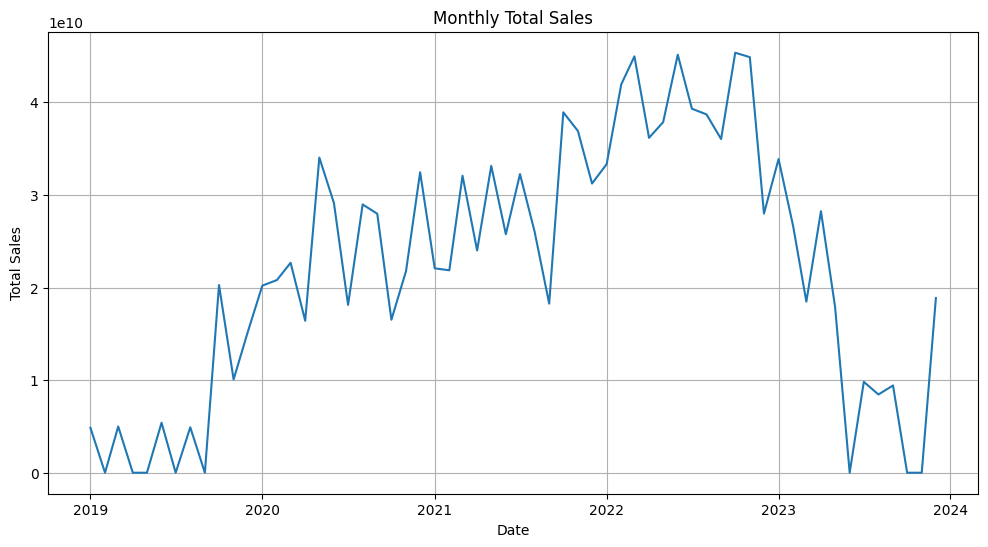


Training monthly series ends: 2022-12-01 00:00:00
Validation monthly series starts: 2023-01-01 00:00:00
Validation monthly series ends: 2023-12-01 00:00:00
Number of periods to forecast: 12

Finding optimal SARIMA parameters using auto_arima...
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=2277.643, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2284.899, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2278.052, Time=0.20 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2281.951, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2283.073, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=2275.647, Time=0.32 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=2274.690, Time=0.48 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : AIC=2275.201, Time=0.43 sec
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(1,1,1)(2,0,1)[12] intercept   : AIC=inf, Time=0.83 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=2280.808

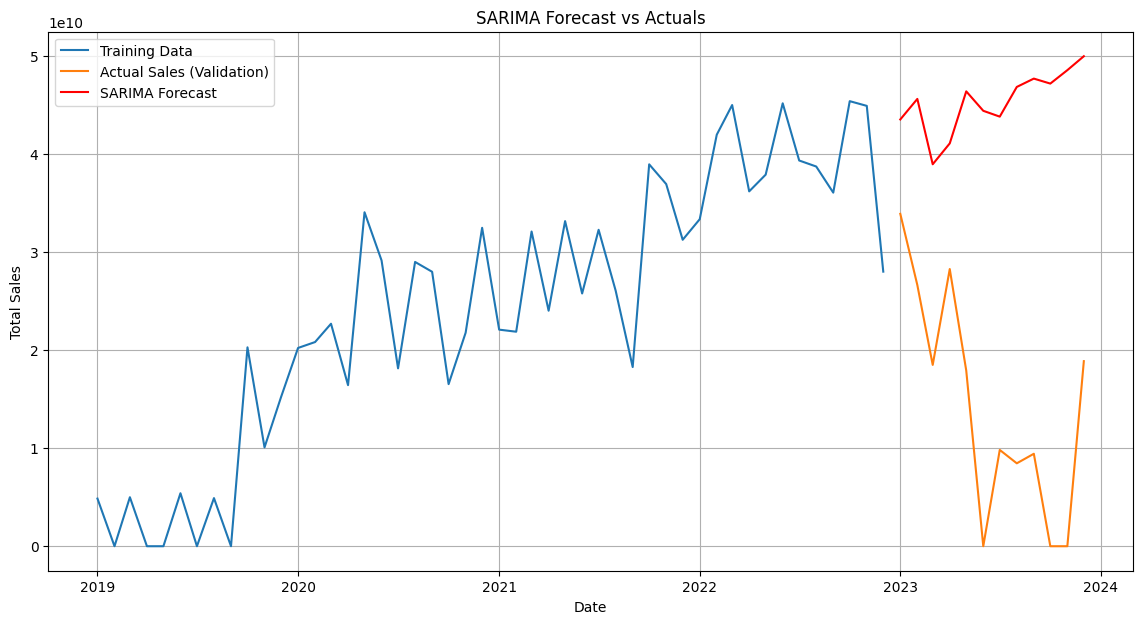


--- SARIMA Model Implementation Complete ---
Next, we will implement Facebook Prophet.


In [22]:
# Prepare data for ARIMA/SARIMA
# Ensure 'Date' column is in datetime format and set it as index
df_sarima = df.copy()
df_sarima['Date'] = pd.to_datetime(df_sarima['Date'])
df_sarima = df_sarima.set_index('Date').sort_index()

monthly_series = df_sarima['Total'].resample('MS').sum()

print("Monthly Series head:")
print(monthly_series.head())
print("\nMonthly Series tail:")
print(monthly_series.tail())
print(f"\nNumber of months in monthly_series: {len(monthly_series)}")

if monthly_series.isnull().any():
    print("\nNaNs found in monthly_series. Filling with 0.")
    monthly_series = monthly_series.fillna(0)

# Plot the monthly series to visualize seasonality and trend
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
plt.plot(monthly_series)
plt.title('Monthly Total Sales')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

train_monthly_series = monthly_series[monthly_series.index <= split_date]
val_monthly_series = monthly_series[monthly_series.index > split_date]

print(f"\nTraining monthly series ends: {train_monthly_series.index.max()}")
print(f"Validation monthly series starts: {val_monthly_series.index.min()}")
print(f"Validation monthly series ends: {val_monthly_series.index.max()}")

n_periods = len(val_monthly_series)
print(f"Number of periods to forecast: {n_periods}")

try:
    from pmdarima import auto_arima
except ImportError:
    print("pmdarima not installed. Installing...")
    %pip install pmdarima
    from pmdarima import auto_arima

print("\nFinding optimal SARIMA parameters using auto_arima...")
# Suppress warnings for a cleaner output
import warnings
warnings.filterwarnings("ignore")

stepwise_model = auto_arima(train_monthly_series, start_p=1, start_q=1,
                            max_p=3, max_q=3, m=12,
                            start_P=0, seasonal=True,
                            d=None, D=None, # Let auto_arima determine differencing orders
                            trace=True,
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True)

print("\nBest SARIMA model parameters:")
print(stepwise_model.summary())

forecast_results = stepwise_model.predict(n_periods=n_periods)

forecast_df_sarima = pd.DataFrame(forecast_results.values, index=val_monthly_series.index, columns=['SARIMA_Forecast'])


print("\nSARIMA Forecast:")
print(forecast_df_sarima.head())
print(forecast_df_sarima.tail())

from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

actuals = val_monthly_series

rmse_sarima = sqrt(mean_squared_error(actuals, forecast_df_sarima['SARIMA_Forecast']))
mae_sarima = mean_absolute_error(actuals, forecast_df_sarima['SARIMA_Forecast'])

print(f'\nSARIMA RMSE: {rmse_sarima}')
print(f'SARIMA MAE: {mae_sarima}')

plt.figure(figsize=(14, 7))
plt.plot(train_monthly_series, label='Training Data')
plt.plot(val_monthly_series, label='Actual Sales (Validation)')
plt.plot(forecast_df_sarima['SARIMA_Forecast'], label='SARIMA Forecast', color='red')
plt.title('SARIMA Forecast vs Actuals')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- SARIMA Model Implementation Complete ---")
print("Next, we will implement Facebook Prophet.")

In [23]:
from flask import Flask, request, jsonify
import pandas as pd
import numpy as np

from pmdarima import auto_arima

app = Flask(__name__)



print("API: Initializing model...")


@app.route('/predict', methods=['GET'])
def predict():
    """
    Predicts future 'Total' values using the SARIMA model.
    Expects 'periods' as a query parameter (number of future periods to predict).
    Example: /predict?periods=12
    """
    try:
        periods_str = request.args.get('periods')
        if not periods_str:
            return jsonify({'error': 'Missing periods parameter'}), 400

        n_periods = int(periods_str)
        if n_periods <= 0:
            return jsonify({'error': 'Periods must be a positive integer'}), 400


        if 'stepwise_model' not in globals():
            return jsonify({'error': 'Model not loaded or trained. Run previous cells.'}), 500

        forecast_results = stepwise_model.predict(n_periods=n_periods)


        last_train_date = stepwise_model.df.index[-1]
        future_dates = pd.date_range(start=last_train_date, periods=n_periods + 1, freq='MS')[1:]

        predictions_df = pd.DataFrame({
            'Date': future_dates.strftime('%Y-%m-%d').tolist(),
            'Predicted_Total': forecast_results.tolist()
        })

        return jsonify(predictions_df.to_dict(orient='records'))

    except ValueError:
        return jsonify({'error': 'Invalid periods parameter. Must be an integer.'}), 400
    except Exception as e:
        return jsonify({'error': str(e)}), 500

print("Flask API setup complete. To run, execute `app.run()` (after setting up ngrok for external access).")
print("Example usage (after running the app and getting the ngrok URL): YOUR_NGROK_URL/predict?periods=12")


API: Initializing model...
Flask API setup complete. To run, execute `app.run()` (after setting up ngrok for external access).
Example usage (after running the app and getting the ngrok URL): YOUR_NGROK_URL/predict?periods=12


In [24]:
app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
